# Persuasion-technique direction comparison

Per-layer cosine similarity between the 5 persuasion-technique directions (each computed vs `neutral` over the everyday categories):
`evidence`, `expert`, `misrepresentation`, `authority`, `logical`.

Run the load cell, then call **`show_heatmap(layer)`** to inspect any single layer's 5×5 cosine matrix (layer 0 = embeddings, 1–35 = transformer blocks). High off-diagonal values mean the techniques' directions point the same way at that layer; lower values reveal where techniques become more distinguishable. The color scale defaults to a shared range (`vmin` = global min across layers) so heatmaps from different layers are directly comparable.

In [3]:
from pathlib import Path

import torch
import torch.nn.functional as F
from safetensors import safe_open


def find_directions_dir():
    """Locate data/directions/ regardless of the notebook's working directory."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / "data" / "directions"
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError("could not locate data/directions")


DIRECTIONS_DIR = find_directions_dir()

# label -> direction folder name (order defines the heatmap rows/cols)
DIRECTIONS = {
    "evidence": "evidence_vs_neutral",
    "expert": "expert_vs_neutral",
    "misrep": "misrepresentation_vs_neutral",
    "authority": "authority_vs_neutral",
    "logical": "logical_vs_neutral",
}
labels = list(DIRECTIONS)


def load_direction(name, key="direction"):
    path = DIRECTIONS_DIR / name / "directions.safetensors"
    with safe_open(str(path), framework="pt") as f:
        return f.get_tensor(key).float()      # [num_layers + 1, hidden_dim]


# stack -> [n_directions, num_layers + 1, hidden_dim]
D = torch.stack([load_direction(DIRECTIONS[k]) for k in labels])
n_dir, n_layers, hidden = D.shape

# per-layer 5x5 cosine matrices -> [num_layers + 1, n_dir, n_dir]
mats = []
for L in range(n_layers):
    v = F.normalize(D[:, L, :], dim=1)        # unit-normalize each direction at layer L
    mats.append(v @ v.T)                       # cosine = normalized dot product
cos_by_layer = torch.stack(mats)

vmin = cos_by_layer.min().item()              # shared color scale across all layers
print(f"directions: {labels}")
print(f"D shape: {tuple(D.shape)}  |  cosine range across layers: "
      f"{vmin:.3f} .. {cos_by_layer.max().item():.3f}")

directions: ['evidence', 'expert', 'misrep', 'authority', 'logical']
D shape: (5, 36, 1536)  |  cosine range across layers: 0.775 .. 1.000


In [15]:
cos_by_layer.min()

tensor(0.7750)

In [4]:
import matplotlib.pyplot as plt


def show_heatmap(layer, vmin=vmin, vmax=1.0, cmap="viridis", annot=True):
    """Plot the 5x5 cosine-similarity heatmap of the technique directions at `layer`.

    layer : int in 0..num_layers (0 = embeddings, 1..35 = transformer blocks).
    vmin  : lower color bound (defaults to the global min so layers are comparable;
            pass None for per-layer auto-scaling to emphasize within-layer structure).
    """
    M = cos_by_layer[layer].numpy()
    if vmin is None:
        vmin = float(M.min())

    fig, ax = plt.subplots(figsize=(5.6, 4.9))
    im = ax.imshow(M, vmin=vmin, vmax=vmax, cmap=cmap)
    ax.set_xticks(range(n_dir), labels, rotation=45, ha="right")
    ax.set_yticks(range(n_dir), labels)
    if annot:
        cut = (vmin + vmax) / 2.0
        for i in range(n_dir):
            for j in range(n_dir):
                ax.text(j, i, f"{M[i, j]:.3f}", ha="center", va="center", fontsize=10,
                        color="white" if M[i, j] < cut else "black")
    ax.set_title(f"Persuasion-technique direction cosine similarity — layer {layer}")
    fig.colorbar(im, ax=ax, shrink=0.85, label="cosine similarity")
    fig.tight_layout()
    plt.show()

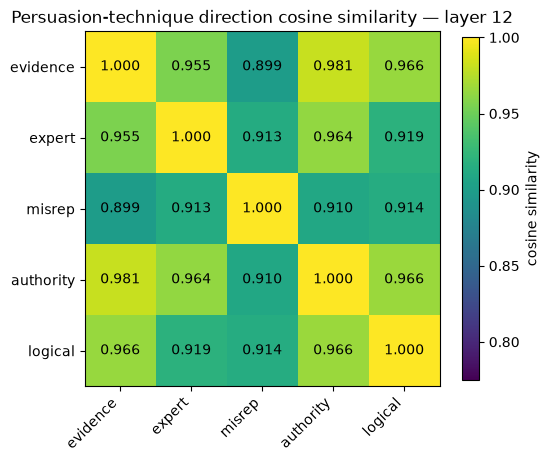

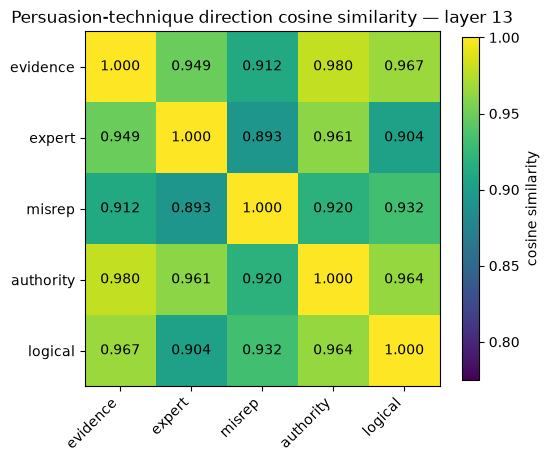

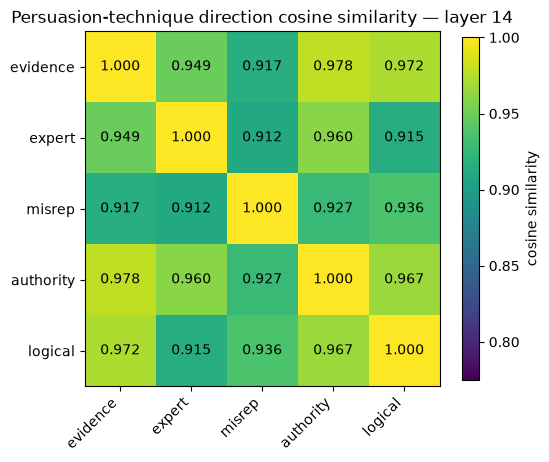

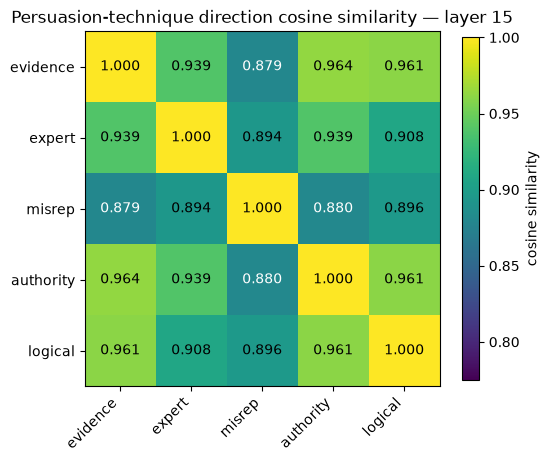

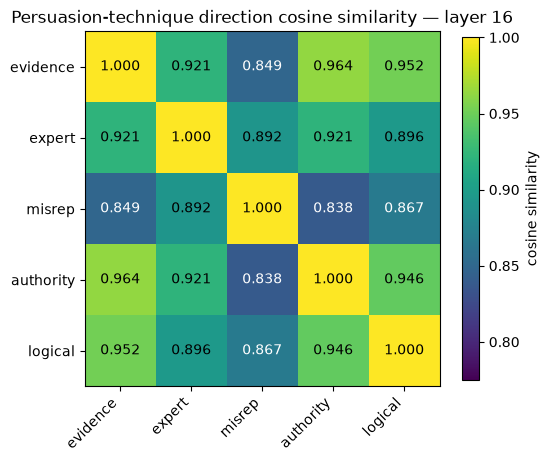

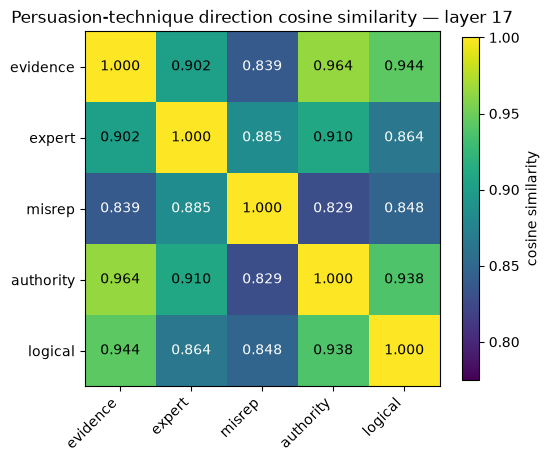

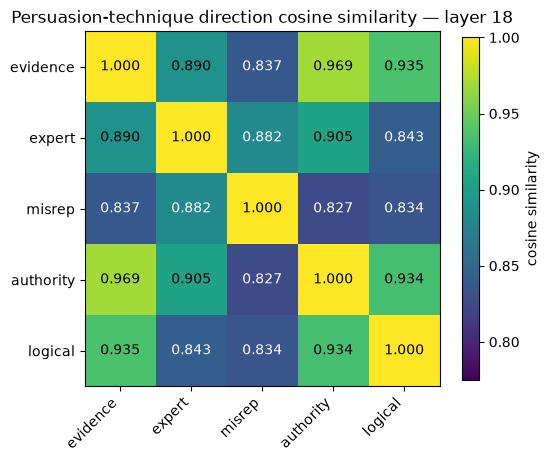

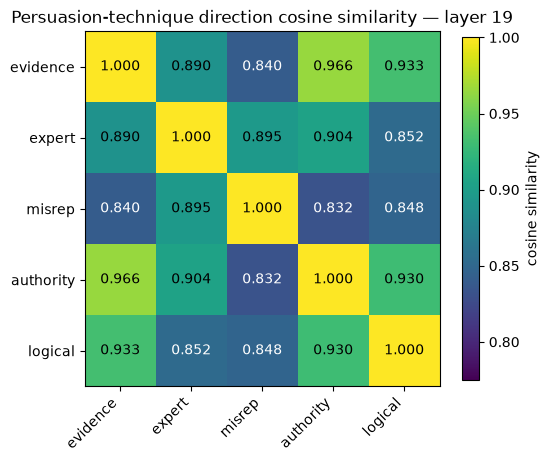

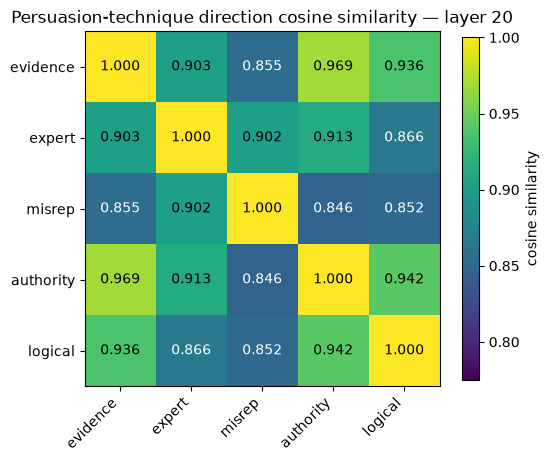

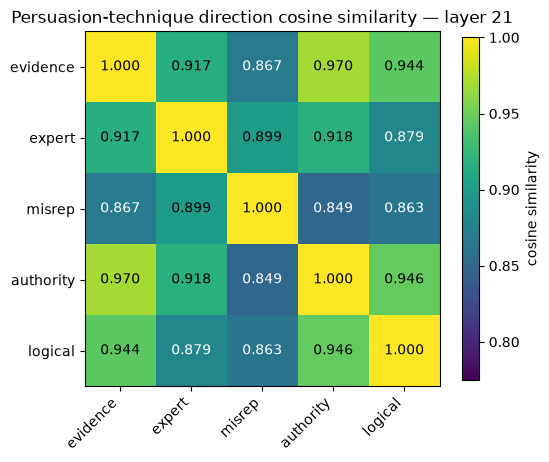

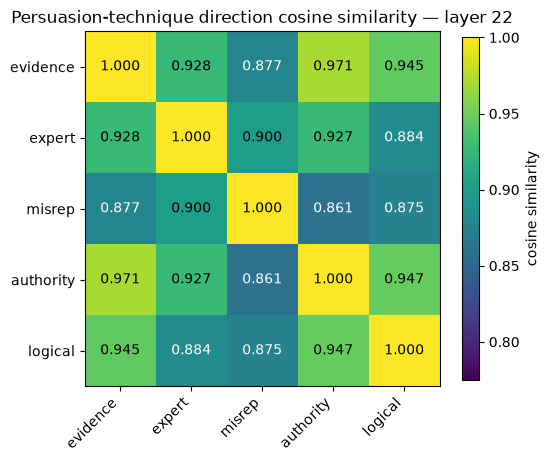

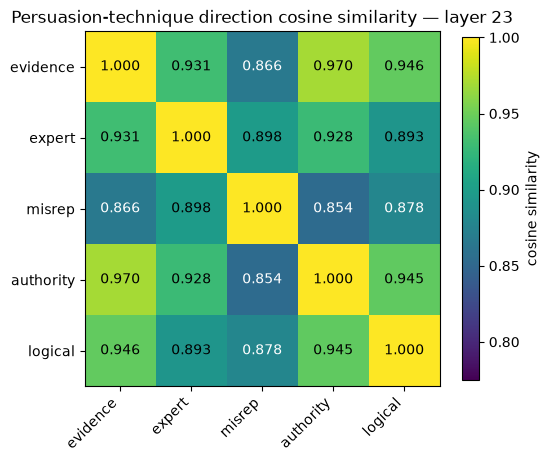

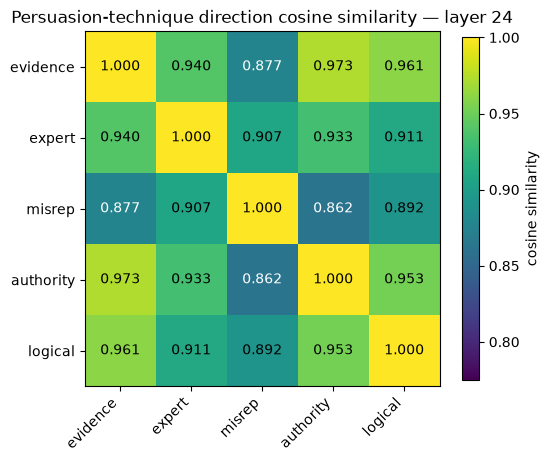

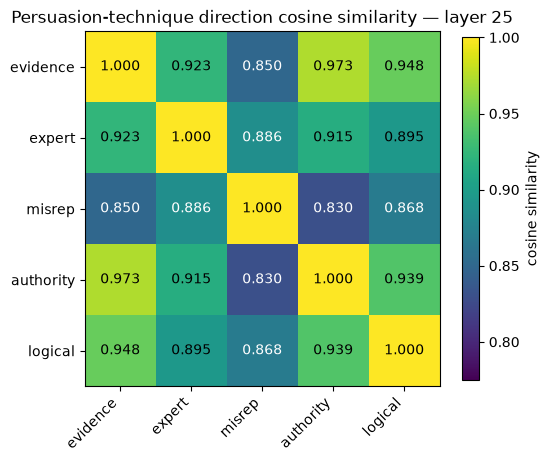

In [5]:
for i in range(12, 26):
    show_heatmap(i)

## Pairwise similarity across layers

Cosine similarity (y) vs layer (x), one line per technique pair. Cosine is symmetric, so there are `C(5, 2) = 10` unique pairs.

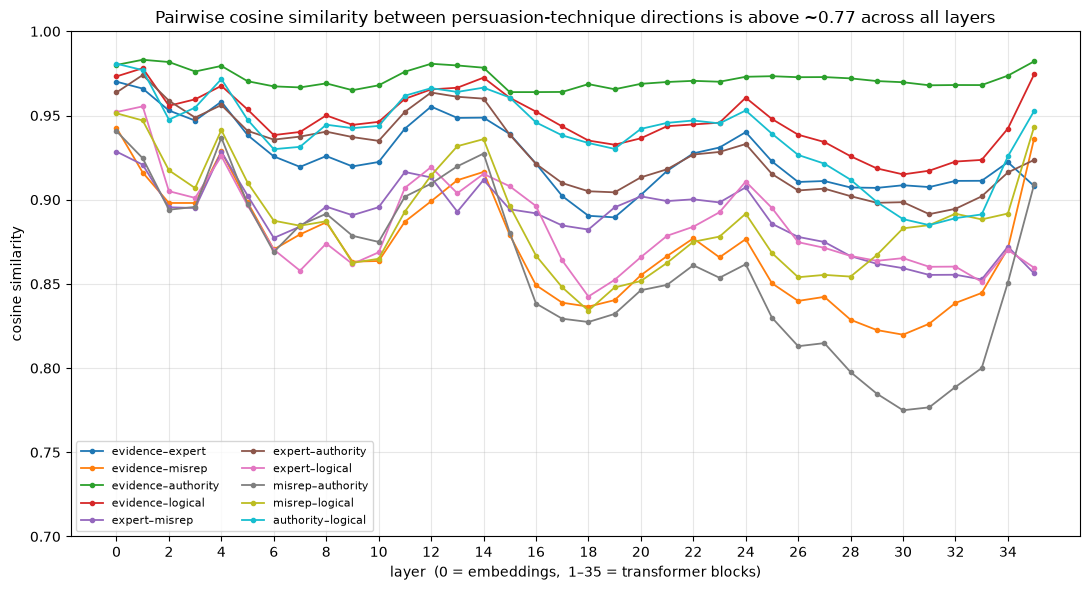

In [9]:
import itertools

import matplotlib.pyplot as plt

layers_x = list(range(n_layers))

fig, ax = plt.subplots(figsize=(11, 6))
for i, j in itertools.combinations(range(n_dir), 2):     # 10 unique technique pairs
    series = cos_by_layer[:, i, j].tolist()
    ax.plot(layers_x, series, marker="o", ms=3, lw=1.3, label=f"{labels[i]}–{labels[j]}")

ax.set_xlabel("layer  (0 = embeddings,  1–35 = transformer blocks)")
ax.set_ylabel("cosine similarity")
ax.set_title("Pairwise cosine similarity between persuasion-technique directions is above ~0.77 across all layers")
ax.set_xticks(range(0, n_layers, 2))
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=8, loc="lower left")
# auto y-range keeps the ~0.78–1.0 band readable; uncomment to force a fixed scale:
ax.set_ylim(0.7, 1.0)
fig.tight_layout()
plt.show()

## Pairwise similarity across layers — Tagalog (`_tl`)

Same 10 technique pairs, but for the Tagalog directions (`*_vs_neutral_tl`).

In [10]:
# Load the Tagalog directions (same techniques, _tl suffix) and build per-layer cosines.
DIRECTIONS_TL = {k: f"{v}_tl" for k, v in DIRECTIONS.items()}

D_tl = torch.stack([load_direction(DIRECTIONS_TL[k]) for k in labels])  # [5, n_layers, hidden]
mats_tl = []
for L in range(n_layers):
    v = F.normalize(D_tl[:, L, :], dim=1)
    mats_tl.append(v @ v.T)
cos_by_layer_tl = torch.stack(mats_tl)                                   # [n_layers, 5, 5]

print(f"tagalog directions: {list(DIRECTIONS_TL.values())}")
print(f"cosine range across layers: {cos_by_layer_tl.min().item():.3f} .. "
      f"{cos_by_layer_tl.max().item():.3f}")

tagalog directions: ['evidence_vs_neutral_tl', 'expert_vs_neutral_tl', 'misrepresentation_vs_neutral_tl', 'authority_vs_neutral_tl', 'logical_vs_neutral_tl']
cosine range across layers: 0.812 .. 1.000


In [16]:
cos_by_layer_tl.min()

tensor(0.8120)

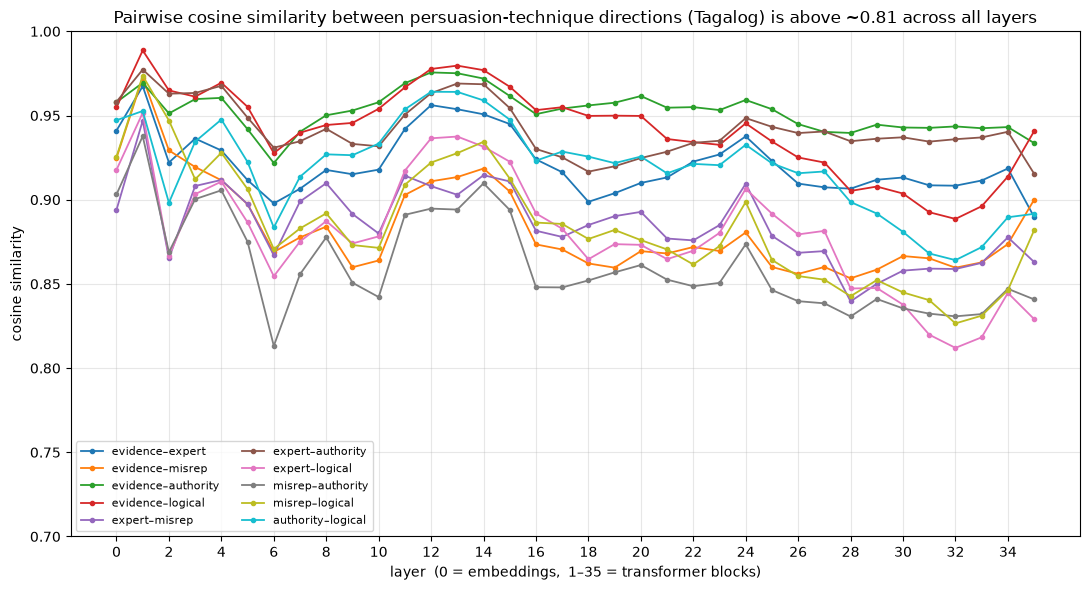

In [18]:
import itertools

import matplotlib.pyplot as plt

layers_x = list(range(n_layers))

fig, ax = plt.subplots(figsize=(11, 6))
for i, j in itertools.combinations(range(n_dir), 2):     # 10 unique technique pairs
    series = cos_by_layer_tl[:, i, j].tolist()
    ax.plot(layers_x, series, marker="o", ms=3, lw=1.3, label=f"{labels[i]}–{labels[j]}")

ax.set_xlabel("layer  (0 = embeddings,  1–35 = transformer blocks)")
ax.set_ylabel("cosine similarity")
ax.set_title("Pairwise cosine similarity between persuasion-technique directions (Tagalog) is above ~0.81 across all layers")
ax.set_xticks(range(0, n_layers, 2))
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=8, loc="lower left")
ax.set_ylim(0.7, 1.0)
fig.tight_layout()
plt.show()

## mean(positive) vs mean(baseline) — `combined_vs_neutral_en`

Per-layer cosine similarity between the two class means stored in the `combined_vs_neutral_en` direction: `mean_positive` (average activation of the combined persuasion responses) and `mean_baseline` (average activation of the neutral responses). Lower cosine at a layer means persuasion pushes the average representation further from neutral there.

cosine range: 0.893 .. 0.997 (min at layer 14)


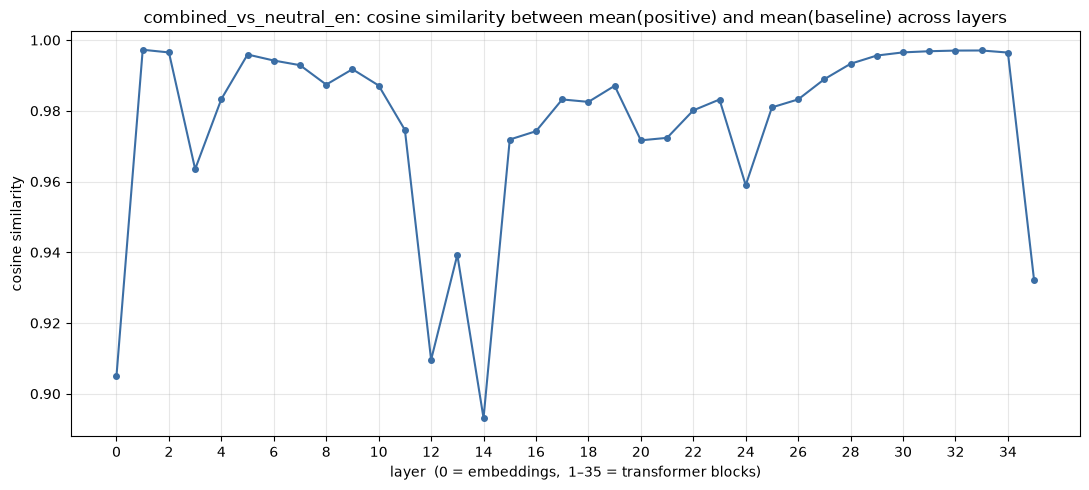

In [19]:
import matplotlib.pyplot as plt

# class means stored in the direction file (each [num_layers + 1, hidden_dim])
mean_pos = load_direction("combined_vs_neutral_en", "mean_positive")
mean_base = load_direction("combined_vs_neutral_en", "mean_baseline")

# per-layer cosine between the positive and baseline means
cos_pos_base = F.cosine_similarity(mean_pos, mean_base, dim=1)   # [num_layers + 1]
print(f"cosine range: {cos_pos_base.min().item():.3f} .. {cos_pos_base.max().item():.3f} "
      f"(min at layer {int(cos_pos_base.argmin())})")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(range(n_layers), cos_pos_base.tolist(), marker="o", ms=4, color="#3b6ea5")
ax.set_xlabel("layer  (0 = embeddings,  1–35 = transformer blocks)")
ax.set_ylabel("cosine similarity")
ax.set_title("combined_vs_neutral_en: cosine similarity between mean(positive) and mean(baseline) across layers")
ax.set_xticks(range(0, n_layers, 2))
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## mean(positive) vs mean(baseline) across directions

Per-layer cosine between `mean_positive` and `mean_baseline` for each of the 5 English technique directions **plus** the combined one — 6 lines, all baselines are `neutral`. Where a line dips, that technique's average response representation is pushed furthest from neutral at that layer.

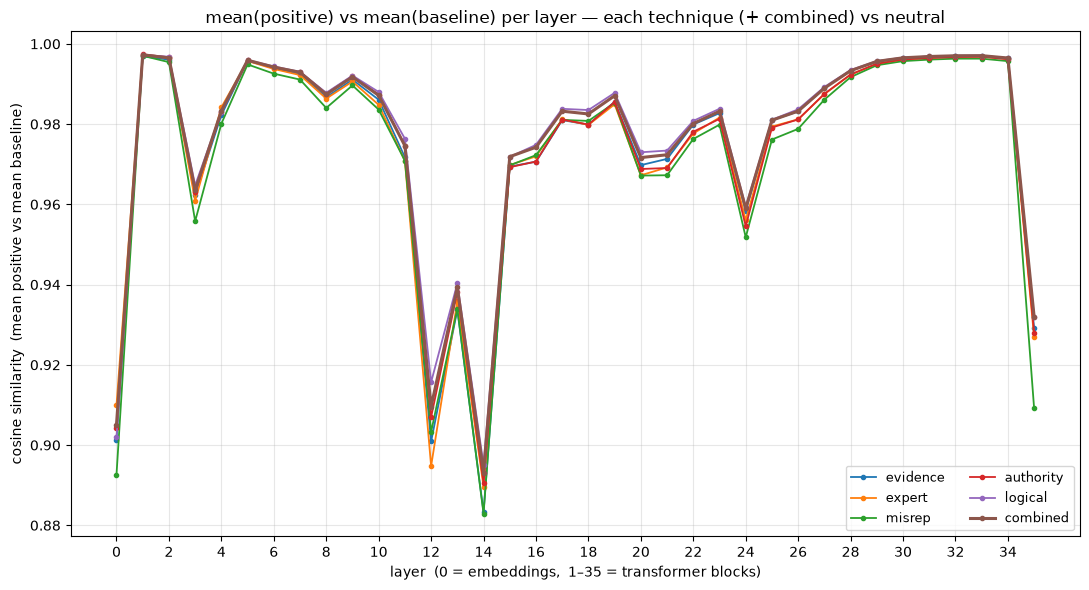

In [20]:
import matplotlib.pyplot as plt

# 5 English technique directions + the combined one (all *_vs_neutral)
posbase_dirs = {**DIRECTIONS, "combined": "combined_vs_neutral_en"}

fig, ax = plt.subplots(figsize=(11, 6))
for name, folder in posbase_dirs.items():
    mp = load_direction(folder, "mean_positive")
    mb = load_direction(folder, "mean_baseline")
    cos = F.cosine_similarity(mp, mb, dim=1)               # [num_layers + 1]
    lw = 2.2 if name == "combined" else 1.3                 # emphasize the combined line
    ax.plot(range(n_layers), cos.tolist(), marker="o", ms=3, lw=lw, label=name)

ax.set_xlabel("layer  (0 = embeddings,  1–35 = transformer blocks)")
ax.set_ylabel("cosine similarity  (mean positive vs mean baseline)")
ax.set_title("mean(positive) vs mean(baseline) per layer — each technique (+ combined) vs neutral")
ax.set_xticks(range(0, n_layers, 2))
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()
plt.show()